In [1]:
import os
import copy
import pickle
import warnings
import math
import pandas as pd
import numpy as np
import numpy.ma as ma
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import bootstrap
from matplotlib.patches import Ellipse,Annulus,Arc,PathPatch

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colors
import palettable
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture,EllipticalAnnulus

from astropy.utils.console import ProgressBar
from astropy.table import QTable
plt.rc('text', usetex=True)
rcParams.update({'axes.linewidth': 1.5})
rcParams.update({'xtick.direction': 'in'})
rcParams.update({'ytick.direction': 'in'})
rcParams.update({'xtick.minor.visible': 'True'})
rcParams.update({'ytick.minor.visible': 'True'})
rcParams.update({'xtick.major.pad': '7.0'})
rcParams.update({'xtick.major.size': '8.0'})
rcParams.update({'xtick.major.width': '1.5'})
rcParams.update({'xtick.minor.pad': '7.0'})
rcParams.update({'xtick.minor.size': '4.0'})
rcParams.update({'xtick.minor.width': '1.5'})
rcParams.update({'ytick.major.pad': '7.0'})
rcParams.update({'ytick.major.size': '8.0'})
rcParams.update({'ytick.major.width': '1.5'})
rcParams.update({'ytick.minor.pad': '7.0'})
rcParams.update({'ytick.minor.size': '4.0'})
rcParams.update({'ytick.minor.width': '1.5'})
rcParams.update({'axes.titlepad': '10.0'})
rcParams.update({'font.size': 35})

In [2]:
fig_dir="/Users/xushuo/work/Papers/CenvsSat/Figure/"
data_dir='/Users/xushuo/work/Project/Simulation/demoandfiles/'

In [3]:
with open(data_dir+'galaxies_tng300_072_concentration_compare_map.txt','rb') as f:
    dict0=pickle.load(f)

In [4]:
cmap0=palettable.cmocean.sequential.Dense_4.mpl_colormap

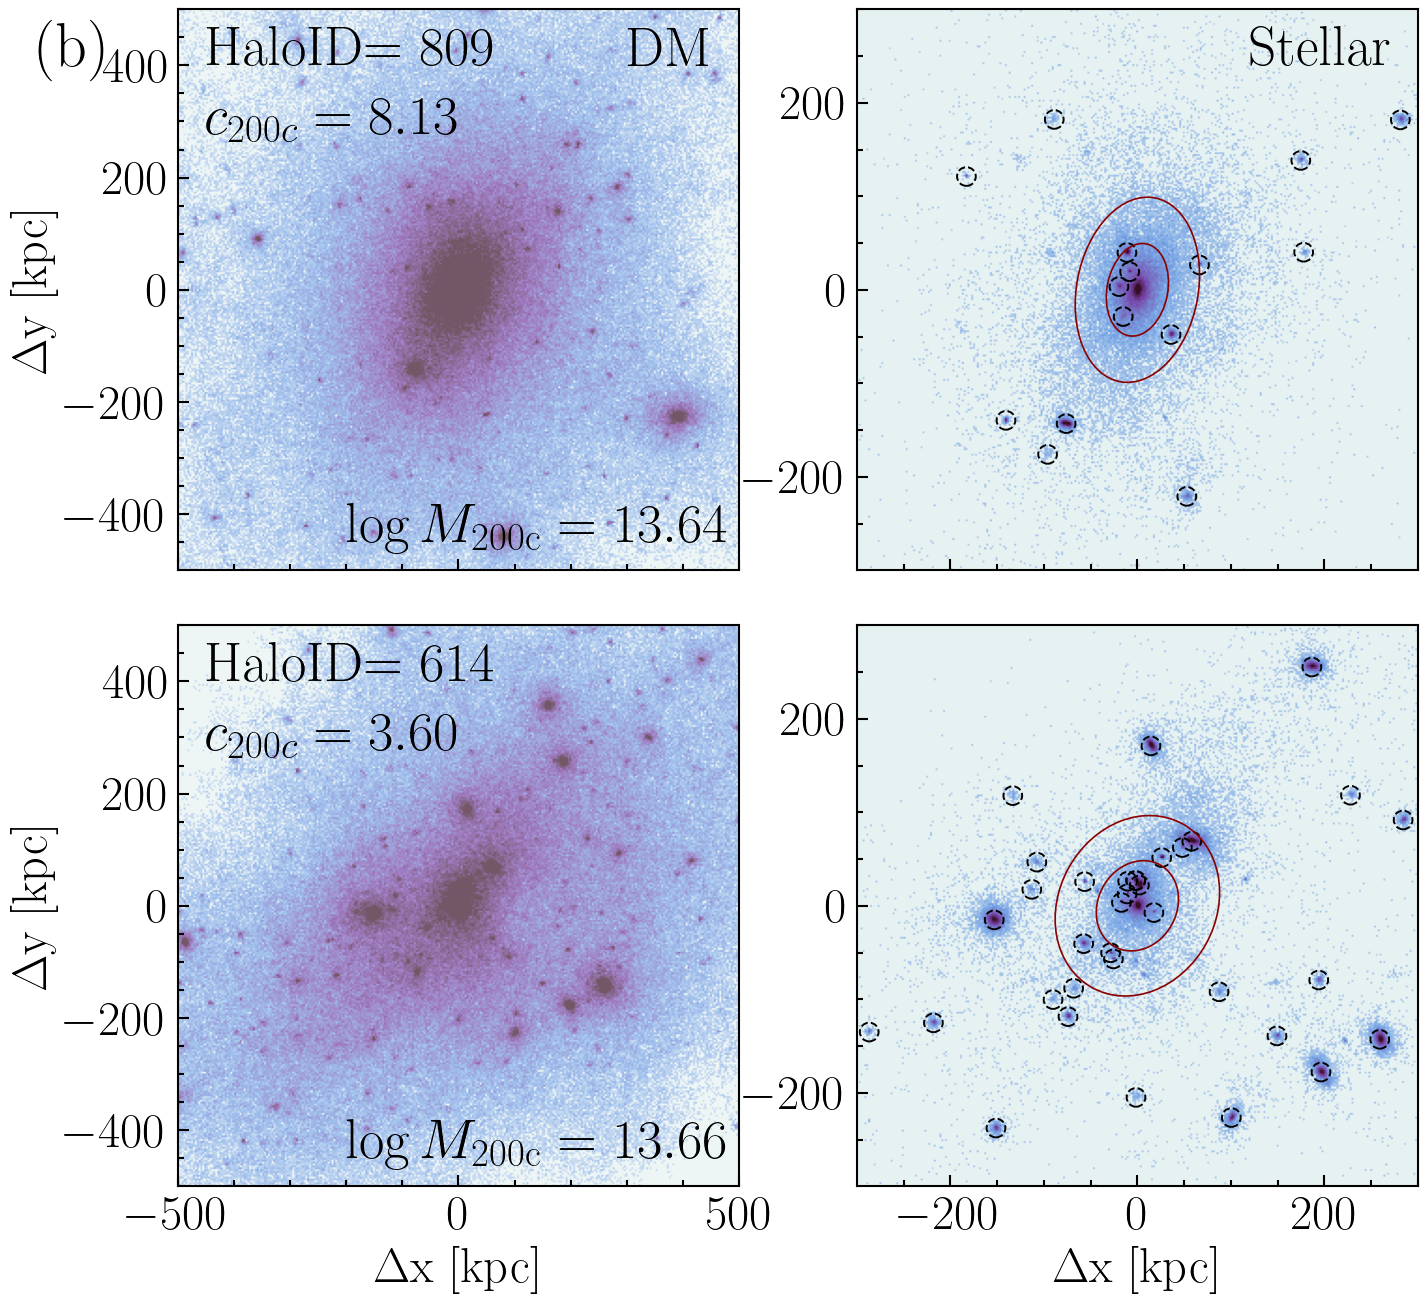

In [12]:
fig = plt.figure(figsize=(16,16),facecolor='none')
gs = fig.add_gridspec(2,2, hspace=0, wspace=0.21)
(ax2,ax4),(ax1,ax3)=gs.subplots(sharex='col')

map_data=dict0[608]['DM']
map_min = map_data[map_data > 0.0].min()
min_value=0.01
norm_factor=map_min/min_value
map_norm=map_data/norm_factor
extent=[-500,500,-500,500]
ax1.imshow(np.arcsinh(np.sqrt(map_norm)),extent=extent, cmap=cmap0,vmin=0,vmax=1,aspect=1,alpha=0.7)
ax1.autoscale(False)
ax1.set_ylabel(r'\rm $\Delta$y [kpc]',fontsize=35)
ax1.text(0.05,0.9,r'{\rm HaloID}$=614$',transform=ax1.transAxes,color='black',fontsize=40)
ax1.text(0.05,0.78,r'$c_{200c}=3.60$',transform=ax1.transAxes,color='black',fontsize=40)
ax2.text(0.8,0.9,r'{\rm DM}',transform=ax2.transAxes,color='black',fontsize=40)
ax1.text(0.3,0.05,r'$\log M_{\rm 200c}=13.66$',transform=ax1.transAxes,color='black',fontsize=40)


map_data=dict0[794]['DM']
map_norm=map_data/norm_factor
ax2.imshow(np.arcsinh(np.sqrt(map_norm)),extent=extent, cmap=cmap0,vmin=0,vmax=1,aspect=1,alpha=0.7)
ax2.autoscale(False)
ax1.set_xlabel(r'\rm $\Delta$x [kpc]',fontsize=35)
ax2.set_ylabel(r'\rm $\Delta$y [kpc]',fontsize=35)
ax2.text(0.05,0.9,r'{\rm HaloID}$=809$',transform=ax2.transAxes,color='black',fontsize=40)
ax2.text(0.05,0.78,r'$c_{200c}=8.13$',transform=ax2.transAxes,color='black',fontsize=40)
ax2.text(0.3,0.05,r'$\log M_{\rm 200c}=13.64$',transform=ax2.transAxes,color='black',fontsize=40)

map_data=dict0[608]['star']
map_min = map_data[map_data > 0.0].min()
min_value=0.01
norm_factor=map_min/min_value
map_norm=map_data/norm_factor
extent=[-300,300,-300,300]
ax3.imshow(np.arcsinh(np.sqrt(map_norm**0.75)),extent=extent,cmap=cmap0,vmin=0,vmax=2,aspect=1)
ax3.autoscale(False)
pos_tab=dict0[608]['subpos']
for i in range(len(pos_tab)):
    x=pos_tab[i][0]
    y=pos_tab[i][1]
    ell=Ellipse((y,x),20,20,angle=0,fill=False,ls='--',lw=1.4,color='black')
    ax3.add_artist(ell)
eps=0.1607
pa=1.067
ell1=Ellipse((0,0),100,100*(1-eps),angle=pa/np.pi*180,fill=False,ls='-',lw=1.2,color='darkred')
ell2=Ellipse((0,0),200,200*(1-eps),angle=pa/np.pi*180,fill=False,ls='-',lw=1.2,color='darkred')
ax3.add_artist(ell1)
ax3.add_artist(ell2)   
ax4.text(0.7,0.9,r'\rm Stellar',transform=ax4.transAxes,color='black',fontsize=40)

map_data=dict0[794]['star']
map_norm=map_data/norm_factor
ax4.imshow(np.arcsinh(np.sqrt(map_norm**0.75)),extent=extent, cmap=cmap0,vmin=0,vmax=2,aspect=1)
ax4.autoscale(False)
pos_tab=dict0[794]['subpos']
for i in range(len(pos_tab)):
    x=pos_tab[i][0]
    y=pos_tab[i][1]
    ell=Ellipse((y,x),20,20,angle=0,fill=False,ls='--',lw=1.4,color='black')
    ax4.add_artist(ell)
eps=0.3505
pa=1.383
ell1=Ellipse((0,0),100,100*(1-eps),angle=pa/np.pi*180,fill=False,ls='-',lw=1.2,color='darkred')
ell2=Ellipse((0,0),200,200*(1-eps),angle=pa/np.pi*180,fill=False,ls='-',lw=1.2,color='darkred')
ax4.add_artist(ell1)
ax4.add_artist(ell2)
ax3.set_xlabel(r'\rm $\Delta$x [kpc]',fontsize=35)

ax2.text(-0.25,0.9,r'\rm (b)',transform=ax2.transAxes,fontsize=45)

for ax in [ax1,ax2,ax3,ax4]:
    ax.set_facecolor('white')

plt.savefig(fig_dir+"Fig1b.pdf",dpi=100)

Text(0.5, 0, '\\rm $\\Delta$x [kpc]')

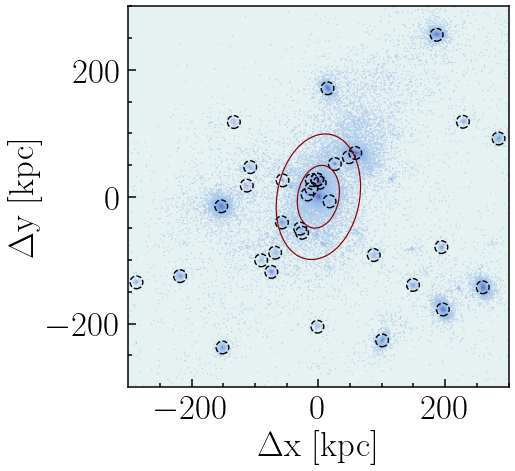

In [9]:
fig = plt.figure(figsize=(7,7))
gs = fig.add_gridspec(1,1, hspace=0, wspace=0.2)
ax4=gs.subplots(sharex='col')

map_data=dict0[608]['DM']
map_min = map_data[map_data > 0.0].min()
min_value=0.01
norm_factor=map_min/min_value
map_norm=map_data/norm_factor





map_data=dict0[608]['star']
map_norm=map_data/norm_factor
ax4.imshow(np.arcsinh(np.sqrt(map_norm**0.5)),extent=extent, cmap=cmap0,vmin=0,vmax=2,aspect=1)
ax4.autoscale(False)
pos_tab=dict0[608]['subpos']
for i in range(len(pos_tab)):
    x=pos_tab[i][0]
    y=pos_tab[i][1]
    ell=Ellipse((y,x),20,20,angle=0,fill=False,ls='--',lw=1.4,color='black')
    ax4.add_artist(ell)
eps=0.3505
pa=1.383
ell1=Ellipse((0,0),100,100*(1-eps),angle=pa/np.pi*180,fill=False,ls='-',lw=1.2,color='darkred')
ell2=Ellipse((0,0),200,200*(1-eps),angle=pa/np.pi*180,fill=False,ls='-',lw=1.2,color='darkred')
ax4.add_artist(ell1)
ax4.add_artist(ell2)
ax4.set_ylabel(r'\rm $\Delta$y [kpc]',fontsize=35)
ax4.set_xlabel(r'\rm $\Delta$x [kpc]',fontsize=35)



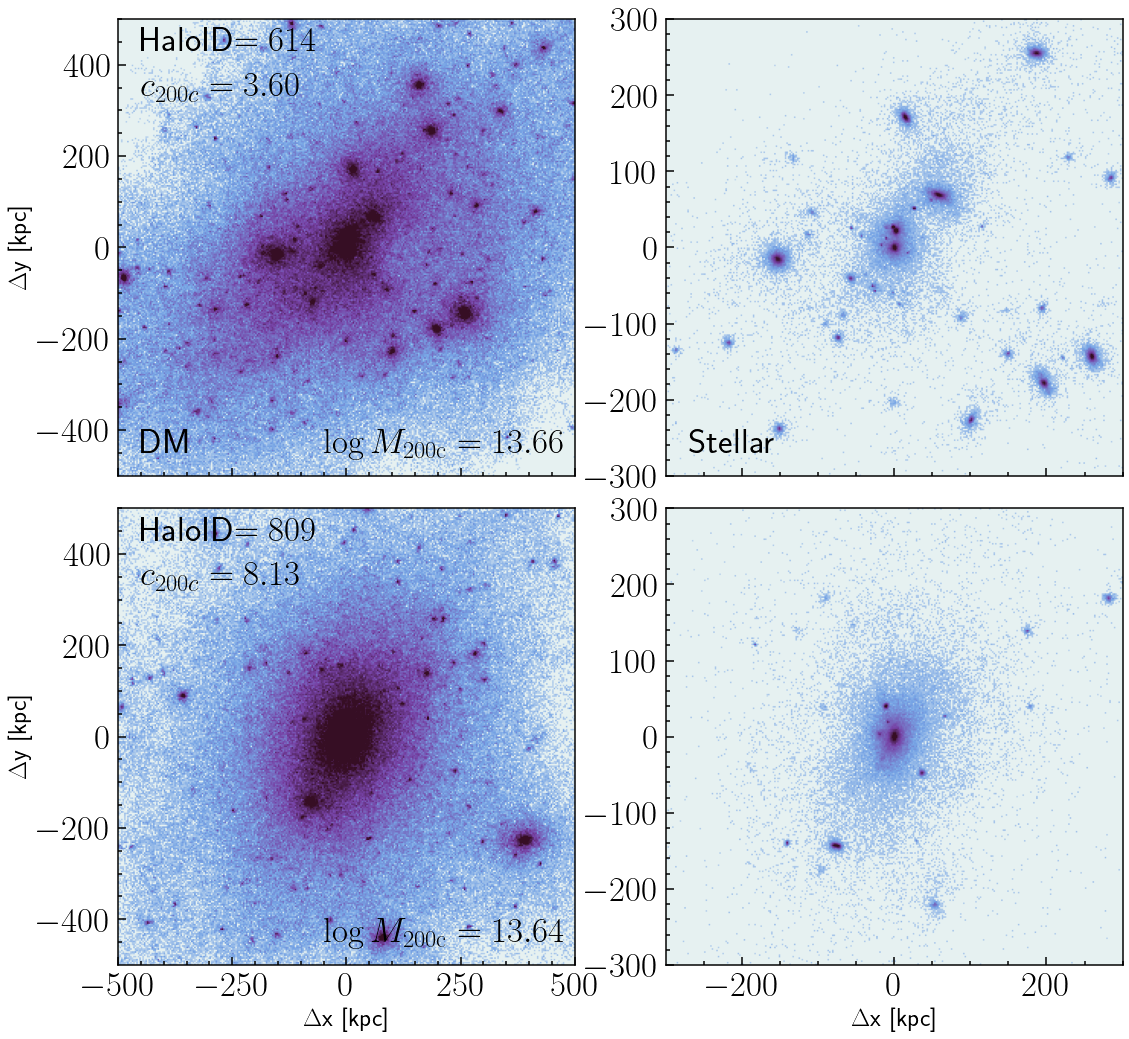

In [6]:
fig = plt.figure(figsize=(18,18))
gs = fig.add_gridspec(2,2, hspace=0, wspace=0.2)
(ax1,ax3),(ax2,ax4)=gs.subplots(sharex='col')

map_data=dict0[608]['DM']
map_min = map_data[map_data > 0.0].min()
min_value=0.01
norm_factor=map_min/min_value
map_norm=map_data/norm_factor
extent=[-500,500,-500,500]
ax1.imshow(np.arcsinh(np.sqrt(map_norm)),extent=extent, cmap=cmap0,vmin=0,vmax=1,aspect=1)
ax1.autoscale(False)
ax1.set_ylabel('$\Delta$y [kpc]',fontsize=25)
ax1.text(0.05,0.93,r'HaloID$=614$',transform=ax1.transAxes,color='black')
ax1.text(0.05,0.83,r'$c_{200c}=3.60$',transform=ax1.transAxes,color='black')
ax1.text(0.05,0.05,r'DM',transform=ax1.transAxes,color='black')
ax1.text(0.45,0.05,r'$\log M_{\rm 200c}=13.66$',transform=ax1.transAxes,color='black')


map_data=dict0[794]['DM']
map_norm=map_data/norm_factor
ax2.imshow(np.arcsinh(np.sqrt(map_norm)),extent=extent, cmap=cmap0,vmin=0,vmax=1,aspect=1)
ax2.autoscale(False)
ax2.set_xlabel('$\Delta$x [kpc]',fontsize=25)
ax2.set_ylabel('$\Delta$y [kpc]',fontsize=25)
ax2.text(0.05,0.93,r'HaloID$=809$',transform=ax2.transAxes,color='black')
ax2.text(0.05,0.83,r'$c_{200c}=8.13$',transform=ax2.transAxes,color='black')
ax2.text(0.45,0.05,r'$\log M_{\rm 200c}=13.64$',transform=ax2.transAxes,color='black')

map_data=dict0[608]['star']
map_min = map_data[map_data > 0.0].min()
min_value=0.01
norm_factor=map_min/min_value
map_norm=map_data/norm_factor
extent=[-300,300,-300,300]
ax3.imshow(np.arcsinh(np.sqrt(map_norm**0.75)),extent=extent,cmap=cmap0,vmin=0,vmax=2,aspect=1)
ax3.autoscale(False)
pos_tab=dict0[608]['subpos']
# for i in range(len(pos_tab)):
#     x=pos_tab[i][0]
#     y=pos_tab[i][1]
#     ell=Ellipse((y,x),15,15,angle=0,fill=False,ls='--',lw=1.2,color='black')
#     ax3.add_artist(ell)
eps=0.1607
pa=1.067
# band=EllipticalAnnulus((0,0),a_in=50,a_out=100,b_in=50*(1-eps),b_out=100*(1-eps),theta=(90-pa/np.pi*180))
# band1=band._to_patch(hatch='x',color='darkred',label=r'$[50,100]${\rm\ kpc}',lw=1)
# ax3.add_patch(band1)    
ax3.text(0.05,0.05,r'Stellar',transform=ax3.transAxes,color='black')

map_data=dict0[794]['star']
map_norm=map_data/norm_factor
ax4.imshow(np.arcsinh(np.sqrt(map_norm**0.75)),extent=extent, cmap=cmap0,vmin=0,vmax=2,aspect=1)
ax4.autoscale(False)
pos_tab=dict0[794]['subpos']
# for i in range(len(pos_tab)):
#     x=pos_tab[i][0]
#     y=pos_tab[i][1]
#     ell=Ellipse((y,x),15,15,angle=0,fill=False,ls='--',lw=1.2,color='black')
#     ax4.add_artist(ell)
eps=0.3505
pa=1.383
# band=EllipticalAnnulus((0,0),a_in=50,a_out=100,b_in=50*(1-eps),b_out=100*(1-eps),theta=(90-pa/np.pi*180))
# band1=band._to_patch(hatch='x',color='darkred',label=r'$[50,100]${\rm\ kpc}',lw=1)
# ax4.add_patch(band1)
ax4.set_xlabel('$\Delta$x [kpc]',fontsize=25)



plt.savefig(fig_dir+"Pre0_0.png",dpi=100)

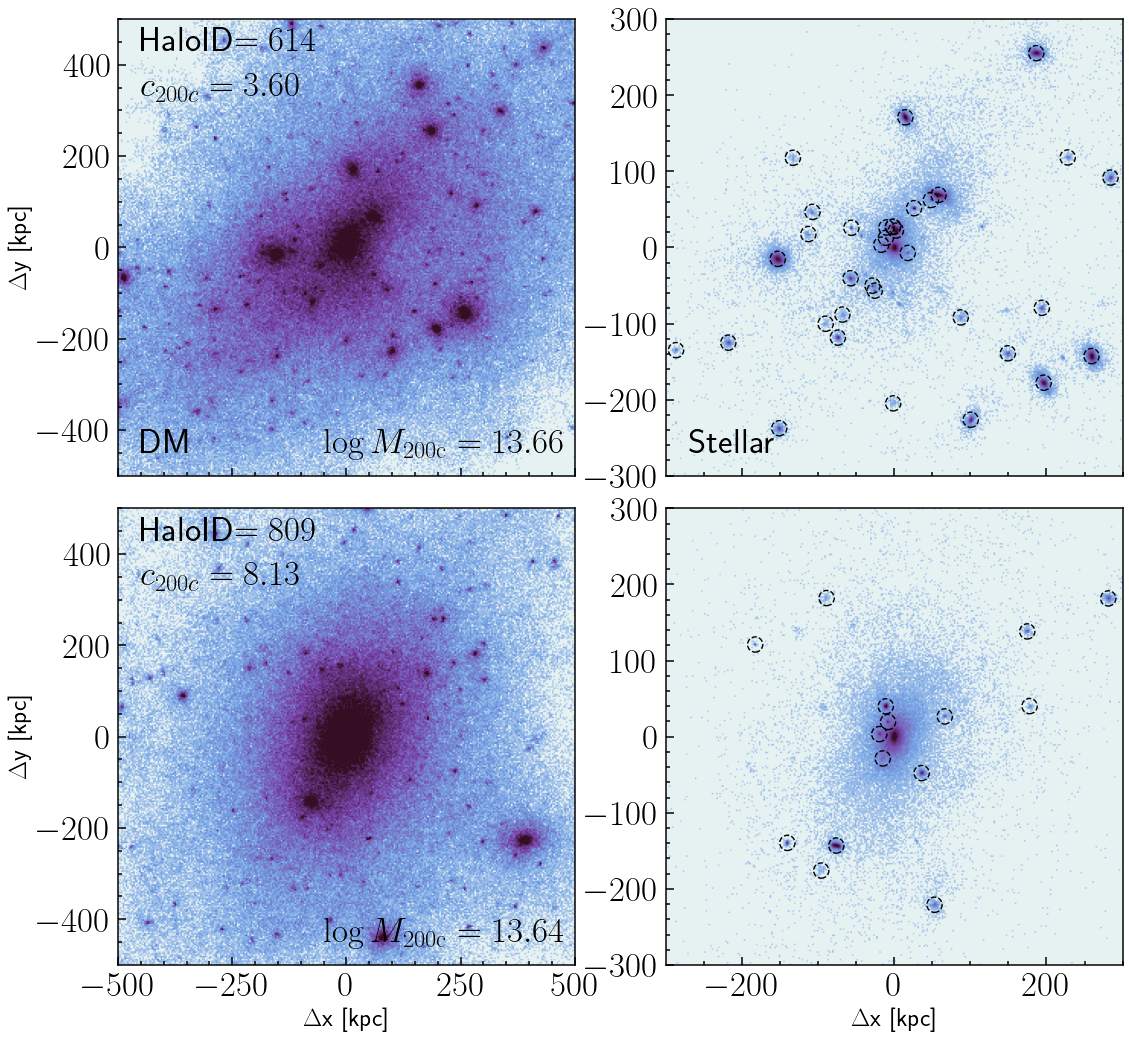

In [57]:
fig = plt.figure(figsize=(18,18))
gs = fig.add_gridspec(2,2, hspace=0, wspace=0.2)
(ax1,ax3),(ax2,ax4)=gs.subplots(sharex='col')

map_data=dict0[608]['DM']
map_min = map_data[map_data > 0.0].min()
min_value=0.01
norm_factor=map_min/min_value
map_norm=map_data/norm_factor
extent=[-500,500,-500,500]
ax1.imshow(np.arcsinh(np.sqrt(map_norm)),extent=extent, cmap=cmap0,vmin=0,vmax=1,aspect=1)
ax1.autoscale(False)
ax1.set_ylabel('$\Delta$y [kpc]',fontsize=25)
ax1.text(0.05,0.93,r'HaloID$=614$',transform=ax1.transAxes,color='black')
ax1.text(0.05,0.83,r'$c_{200c}=3.60$',transform=ax1.transAxes,color='black')
ax1.text(0.05,0.05,r'DM',transform=ax1.transAxes,color='black')
ax1.text(0.45,0.05,r'$\log M_{\rm 200c}=13.66$',transform=ax1.transAxes,color='black')


map_data=dict0[794]['DM']
map_norm=map_data/norm_factor
ax2.imshow(np.arcsinh(np.sqrt(map_norm)),extent=extent, cmap=cmap0,vmin=0,vmax=1,aspect=1)
ax2.autoscale(False)
ax2.set_xlabel('$\Delta$x [kpc]',fontsize=25)
ax2.set_ylabel('$\Delta$y [kpc]',fontsize=25)
ax2.text(0.05,0.93,r'HaloID$=809$',transform=ax2.transAxes,color='black')
ax2.text(0.05,0.83,r'$c_{200c}=8.13$',transform=ax2.transAxes,color='black')
ax2.text(0.45,0.05,r'$\log M_{\rm 200c}=13.64$',transform=ax2.transAxes,color='black')


map_data=dict0[608]['star']
map_min = map_data[map_data > 0.0].min()
min_value=0.01
norm_factor=map_min/min_value
map_norm=map_data/norm_factor
extent=[-300,300,-300,300]
ax3.imshow(np.arcsinh(np.sqrt(map_norm**0.75)),extent=extent,cmap=cmap0,vmin=0,vmax=2,aspect=1)
ax3.autoscale(False)
pos_tab=dict0[608]['subpos']
for i in range(len(pos_tab)):
    x=pos_tab[i][0]
    y=pos_tab[i][1]
    ell=Ellipse((y,x),20,20,angle=0,fill=False,ls='--',lw=1.4,color='black')
    ax3.add_artist(ell)
eps=0.1607
pa=1.067
# band=EllipticalAnnulus((0,0),a_in=50,a_out=100,b_in=50*(1-eps),b_out=100*(1-eps),theta=(90-pa/np.pi*180))
# band1=band._to_patch(hatch='x',color='darkred',label=r'$[50,100]${\rm\ kpc}',lw=1)
# ax3.add_patch(band1)    
ax3.text(0.05,0.05,r'Stellar',transform=ax3.transAxes,color='black')

map_data=dict0[794]['star']
map_norm=map_data/norm_factor
ax4.imshow(np.arcsinh(np.sqrt(map_norm**0.75)),extent=extent, cmap=cmap0,vmin=0,vmax=2,aspect=1)
ax4.autoscale(False)
pos_tab=dict0[794]['subpos']
for i in range(len(pos_tab)):
    x=pos_tab[i][0]
    y=pos_tab[i][1]
    ell=Ellipse((y,x),20,20,angle=0,fill=False,ls='--',lw=1.4,color='black')
    ax4.add_artist(ell)
eps=0.3505
pa=1.383
# band=EllipticalAnnulus((0,0),a_in=50,a_out=100,b_in=50*(1-eps),b_out=100*(1-eps),theta=(90-pa/np.pi*180))
# band1=band._to_patch(hatch='x',color='darkred',label=r'$[50,100]${\rm\ kpc}',lw=1)
# ax4.add_patch(band1)
ax4.set_xlabel('$\Delta$x [kpc]',fontsize=25)

plt.savefig(fig_dir+"Pre0_1.png",dpi=100)

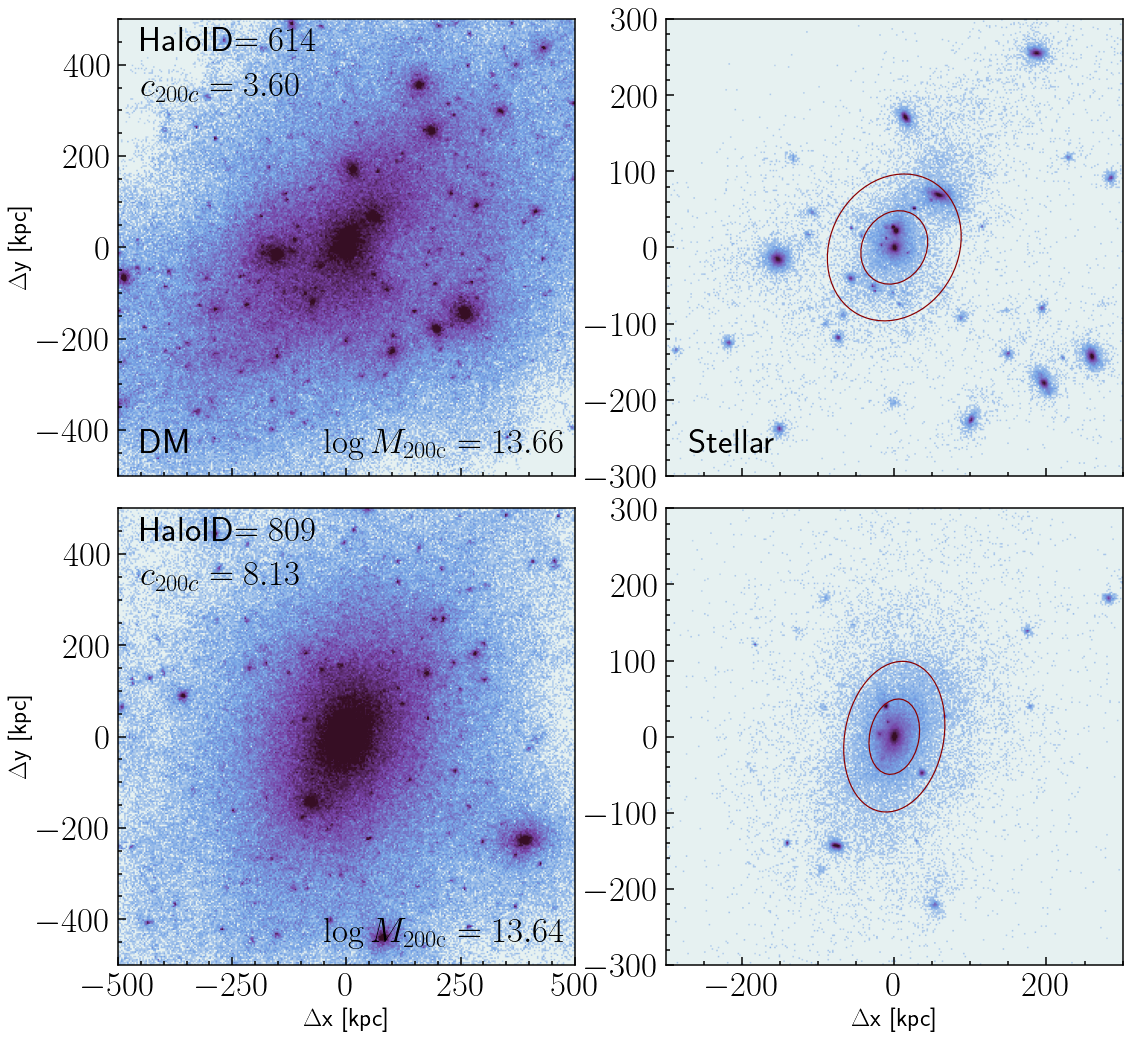

In [56]:
fig = plt.figure(figsize=(18,18))
gs = fig.add_gridspec(2,2, hspace=0, wspace=0.2)
(ax1,ax3),(ax2,ax4)=gs.subplots(sharex='col')

map_data=dict0[608]['DM']
map_min = map_data[map_data > 0.0].min()
min_value=0.01
norm_factor=map_min/min_value
map_norm=map_data/norm_factor
extent=[-500,500,-500,500]
ax1.imshow(np.arcsinh(np.sqrt(map_norm)),extent=extent, cmap=cmap0,vmin=0,vmax=1,aspect=1)
ax1.autoscale(False)
ax1.set_ylabel('$\Delta$y [kpc]',fontsize=25)
ax1.text(0.05,0.93,r'HaloID$=614$',transform=ax1.transAxes,color='black')
ax1.text(0.05,0.83,r'$c_{200c}=3.60$',transform=ax1.transAxes,color='black')
ax1.text(0.05,0.05,r'DM',transform=ax1.transAxes,color='black')
ax1.text(0.45,0.05,r'$\log M_{\rm 200c}=13.66$',transform=ax1.transAxes,color='black')

map_data=dict0[794]['DM']
map_norm=map_data/norm_factor
ax2.imshow(np.arcsinh(np.sqrt(map_norm)),extent=extent, cmap=cmap0,vmin=0,vmax=1,aspect=1)
ax2.autoscale(False)
ax2.set_xlabel('$\Delta$x [kpc]',fontsize=25)
ax2.set_ylabel('$\Delta$y [kpc]',fontsize=25)
ax2.text(0.05,0.93,r'HaloID$=809$',transform=ax2.transAxes,color='black')
ax2.text(0.05,0.83,r'$c_{200c}=8.13$',transform=ax2.transAxes,color='black')
ax2.text(0.45,0.05,r'$\log M_{\rm 200c}=13.64$',transform=ax2.transAxes,color='black')

map_data=dict0[608]['star']
map_min = map_data[map_data > 0.0].min()
min_value=0.01
norm_factor=map_min/min_value
map_norm=map_data/norm_factor
extent=[-300,300,-300,300]
ax3.imshow(np.arcsinh(np.sqrt(map_norm**0.75)),extent=extent,cmap=cmap0,vmin=0,vmax=2,aspect=1)
ax3.autoscale(False)
pos_tab=dict0[608]['subpos']
# for i in range(len(pos_tab)):
#     x=pos_tab[i][0]
#     y=pos_tab[i][1]
#     ell=Ellipse((y,x),20,20,angle=0,fill=False,ls='--',lw=1.4,color='black')
#     ax3.add_artist(ell)
eps=0.1607
pa=1.067
ell1=Ellipse((0,0),100,100*(1-eps),angle=pa/np.pi*180,fill=False,ls='-',lw=1.2,color='darkred')
ell2=Ellipse((0,0),200,200*(1-eps),angle=pa/np.pi*180,fill=False,ls='-',lw=1.2,color='darkred')
ax3.add_artist(ell1)
ax3.add_artist(ell2)  
ax3.text(0.05,0.05,r'Stellar',transform=ax3.transAxes,color='black')

map_data=dict0[794]['star']
map_norm=map_data/norm_factor
ax4.imshow(np.arcsinh(np.sqrt(map_norm**0.75)),extent=extent, cmap=cmap0,vmin=0,vmax=2,aspect=1)
ax4.autoscale(False)
pos_tab=dict0[794]['subpos']
# for i in range(len(pos_tab)):
#     x=pos_tab[i][0]
#     y=pos_tab[i][1]
#     ell=Ellipse((y,x),20,20,angle=0,fill=False,ls='--',lw=1.4,color='black')
#     ax4.add_artist(ell)
eps=0.3505
pa=1.383
ell1=Ellipse((0,0),100,100*(1-eps),angle=pa/np.pi*180,fill=False,ls='-',lw=1.2,color='darkred')
ell2=Ellipse((0,0),200,200*(1-eps),angle=pa/np.pi*180,fill=False,ls='-',lw=1.2,color='darkred')
ax4.add_artist(ell1)
ax4.add_artist(ell2)
ax4.set_xlabel('$\Delta$x [kpc]',fontsize=25)
#ax4.legend(loc=2,labelcolor='Black',frameon=False,labelspacing=0.3,borderaxespad=0.2)

plt.savefig(fig_dir+"Pre0_2.png",dpi=100)

In [32]:
pa/np.pi*180

79.24006306659285

In [33]:
90-pa/np.pi*180

10.759936933407147

In [54]:
13.49-np.log10(0.6774)

13.659154807691388

In [55]:
13.47-np.log10(0.6774)

13.639154807691389